# General dataset statistics

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from cmcrameri import cm as cmc # Correct import
import numpy as np

# Set the aesthetic style of the plots
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Define some nice Fabio Crameri colormaps from cmcrameri
# NOTE: These are the correct names for the cmcrameri library
cmap_ice = cmc.batlow      # A nice blue-to-red colormap
cmap_haline = cmc.lajolla  # A blue-to-orange colormap
cmap_turbid = cmc.vik      # A blue-to-yellow-to-red colormap
cmap_matter = cmc.imola    # A purple-to-yellow colormap

# Load your data
df = pd.read_csv("/mnt/bulk-saturn/maralampert/genhist/dataframes/brca_subtypes.csv")

# Helper function to generate a palette from a colormap
def generate_palette_from_cmap(cmap, n_colors):
    """Generates a list of colors from a colormap for a given number of categories."""
    return [cmap(i) for i in np.linspace(0, 1, n_colors)]

# Check for missing values in key columns
print("Missing values in key columns:")
print(df[['age_at_initial_pathologic_diagnosis', 'gender', 'ajcc_pathologic_tumor_stage',
         'vital_status', 'OS', 'OS.time']].isnull().sum())

# Get a sense of the data types
print("\nData types:")
print(df[['age_at_initial_pathologic_diagnosis', 'gender', 'ajcc_pathologic_tumor_stage',
         'vital_status', 'OS', 'OS.time']].dtypes)


Missing values in key columns:
age_at_initial_pathologic_diagnosis    1
gender                                 0
ajcc_pathologic_tumor_stage            0
vital_status                           0
OS                                     0
OS.time                                1
dtype: int64

Data types:
age_at_initial_pathologic_diagnosis    float64
gender                                  object
ajcc_pathologic_tumor_stage             object
vital_status                            object
OS                                     float64
OS.time                                float64
dtype: object


In [ ]:
# --- Plotting General Dataset Statistics ---

# Idea 1: Age Distribution at Diagnosis
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age_at_initial_pathologic_diagnosis', bins=30,
            color=cmap_ice(0.6), kde=True, edgecolor='black', alpha=0.7)
plt.title('Age Distribution at Initial Pathologic Diagnosis', fontsize=16)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1299882/2444804579.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', ax=axes[0], palette=gender_palette)
/tmp/ipykernel_1299882/2444804579.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ajcc_pathologic_tumor_stage', ax=axes[1],
/tmp/ipykernel_1299882/2444804579.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='menopause_status', ax=axes[2], palette=menopause_palette)
/tmp/ipykernel_1299882/2444804579.py:28: FutureWarning: 

Passing `palette` without assigning `hue` 

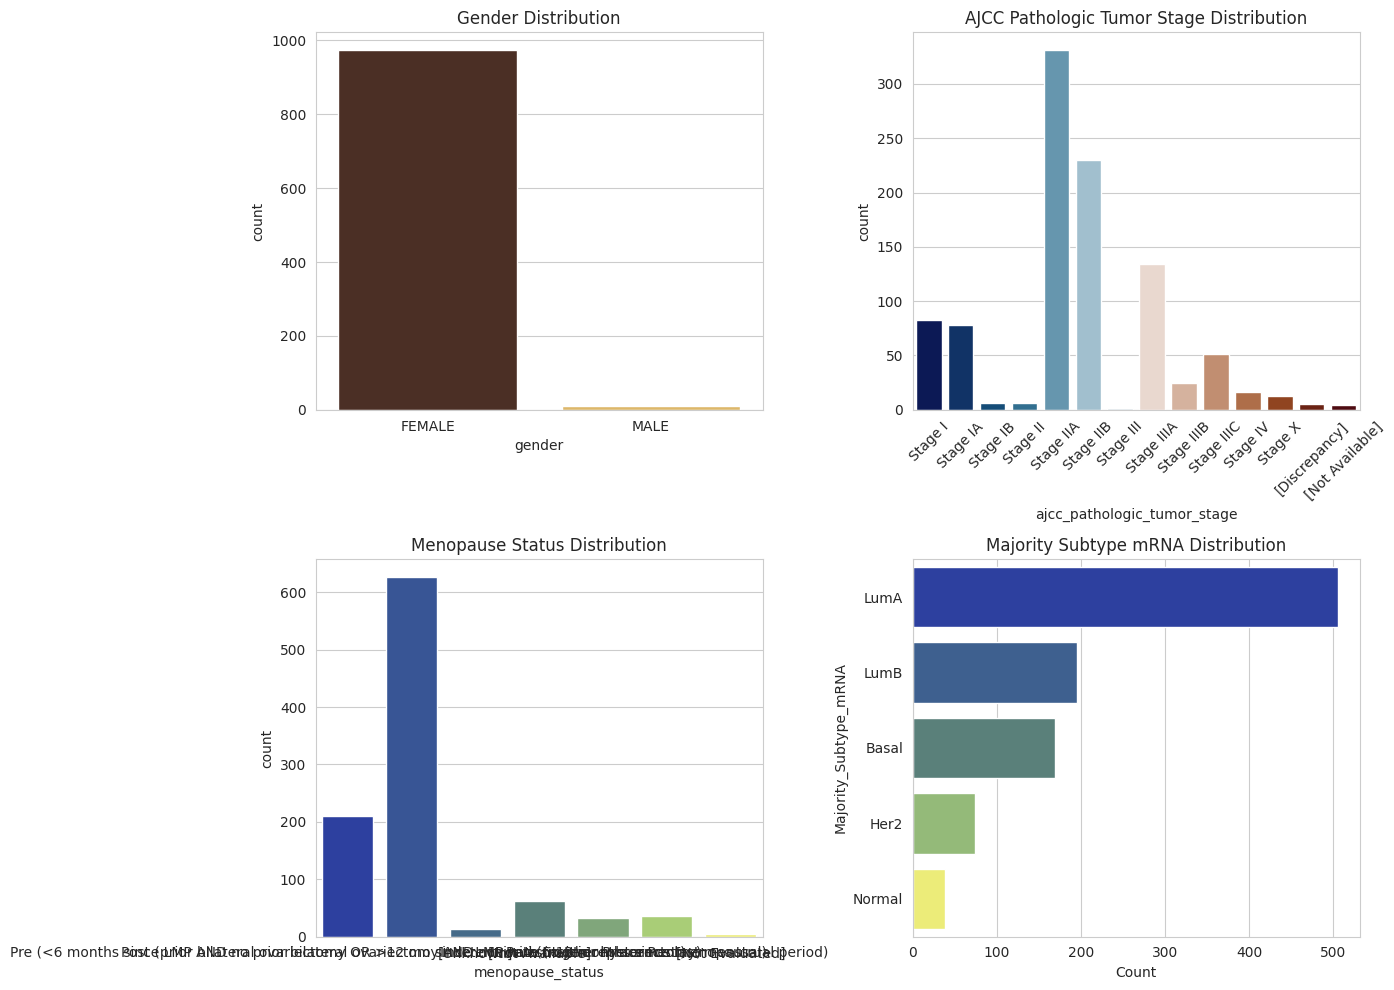

In [11]:
# Idea 2: Distribution of Clinical Variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Gender Distribution (2 categories)
gender_palette = [cmap_haline(0.2), cmap_haline(0.8)]
sns.countplot(data=df, x='gender', ax=axes[0], palette=gender_palette)
axes[0].set_title('Gender Distribution')

# Tumor Stage Distribution (multiple categories)
n_stages = len(df['ajcc_pathologic_tumor_stage'].dropna().unique())
stage_palette = generate_palette_from_cmap(cmap_turbid, n_stages)
sns.countplot(data=df, x='ajcc_pathologic_tumor_stage', ax=axes[1], 
             order=sorted(df['ajcc_pathologic_tumor_stage'].dropna().unique()),
             palette=stage_palette)
axes[1].set_title('AJCC Pathologic Tumor Stage Distribution')
axes[1].tick_params(axis='x', rotation=45)

# Menopause Status Distribution (multiple categories)
n_menopause = len(df['menopause_status'].dropna().unique())
menopause_palette = generate_palette_from_cmap(cmap_matter, n_menopause)
sns.countplot(data=df, x='menopause_status', ax=axes[2], palette=menopause_palette)
axes[2].set_title('Menopause Status Distribution')

# Majority Subtype mRNA Distribution (multiple categories)
n_subtypes = len(df['Majority_Subtype_mRNA'].dropna().unique())
subtype_palette = generate_palette_from_cmap(cmap_matter, n_subtypes)
sns.countplot(data=df, y='Majority_Subtype_mRNA', ax=axes[3], 
             order=df['Majority_Subtype_mRNA'].value_counts().index,
             palette=subtype_palette)
axes[3].set_title('Majority Subtype mRNA Distribution')
axes[3].set_xlabel('Count')

plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

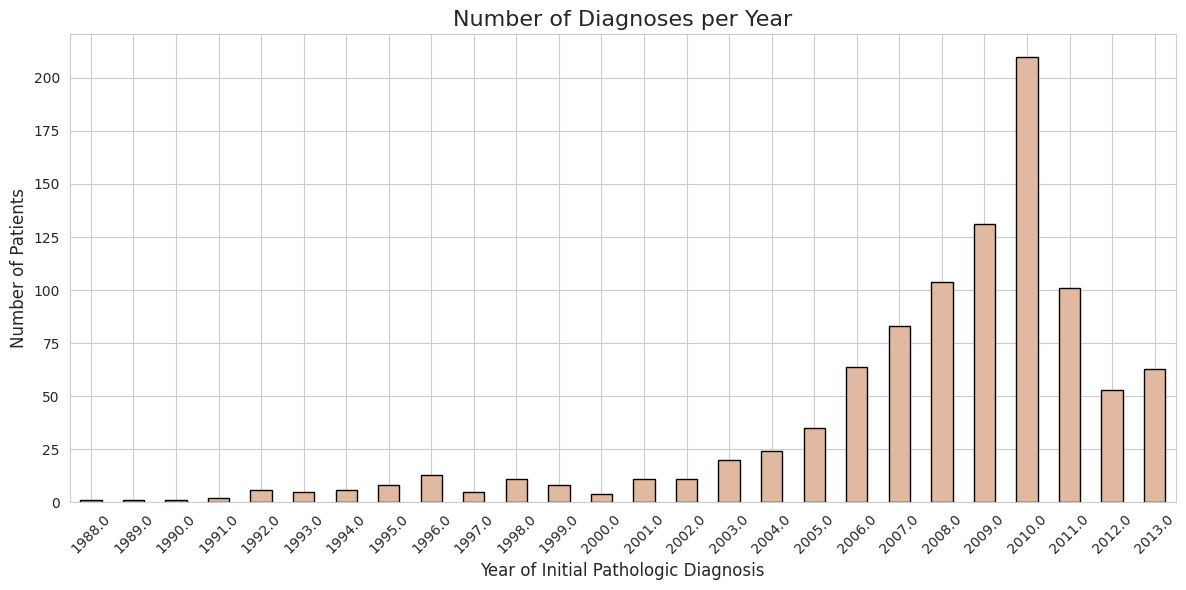

In [12]:
# Idea 3: Temporal Trends in Diagnosis
plt.figure(figsize=(12, 6))
df['initial_pathologic_dx_year'].value_counts().sort_index().plot(kind='bar', 
                                                           color=cmap_turbid(0.6),
                                                           edgecolor='black')
plt.title('Number of Diagnoses per Year', fontsize=16)
plt.xlabel('Year of Initial Pathologic Diagnosis', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Number of NaNs in 'OS.time': 1
Number of NaNs in 'OS': 0

Dropped 1 rows with missing OS data.
New dataframe shape for OS analysis: (983, 43)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

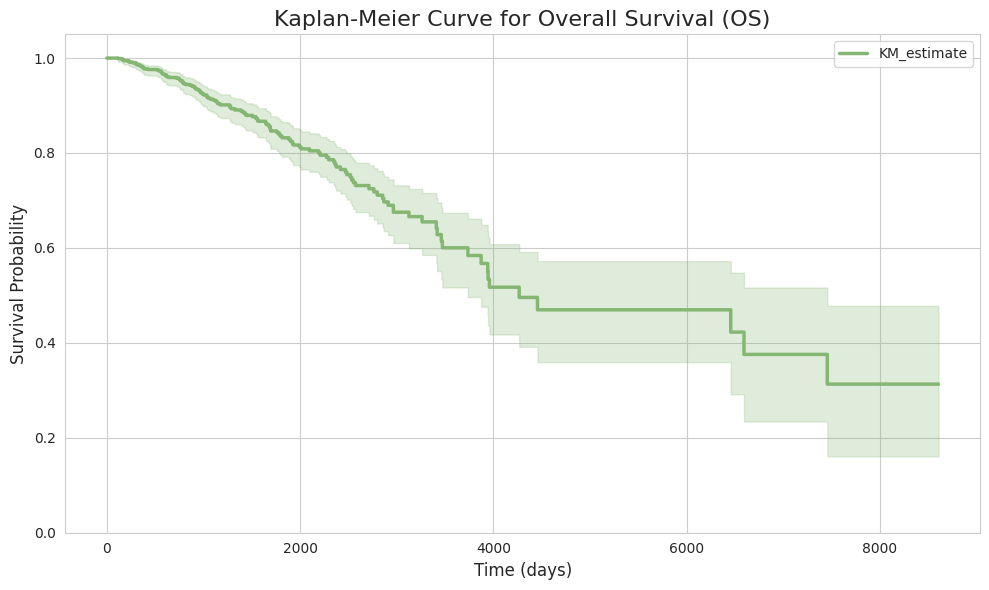

In [17]:
# First, let's check how many missing values we have in the required columns
print("Number of NaNs in 'OS.time':", df['OS.time'].isnull().sum())
print("Number of NaNs in 'OS':", df['OS'].isnull().sum())

# Create a new dataframe with only the rows that have complete data for OS analysis
# We use .copy() to avoid a SettingWithCopyWarning
df_os_clean = df.dropna(subset=['OS.time', 'OS']).copy()

print(f"\nDropped {len(df) - len(df_os_clean)} rows with missing OS data.")
print(f"New dataframe shape for OS analysis: {df_os_clean.shape}")

# Now, fit the model using the cleaned data
kmf = KaplanMeierFitter()
kmf.fit(durations=df_os_clean['OS.time'], event_observed=df_os_clean['OS'])

plt.figure(figsize=(10, 6))
kmf.plot_survival_function(color=cmap_matter(0.7), linewidth=2.5)
plt.title('Kaplan-Meier Curve for Overall Survival (OS)', fontsize=16)
plt.xlabel('Time (days)', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because


--- Preparing DSS Analysis ---
Number of NaNs in 'DSS.time': 1
Number of NaNs in 'DSS': 19
Dropped 20 rows with missing DSS data.
New dataframe shape for DSS analysis: (964, 43)


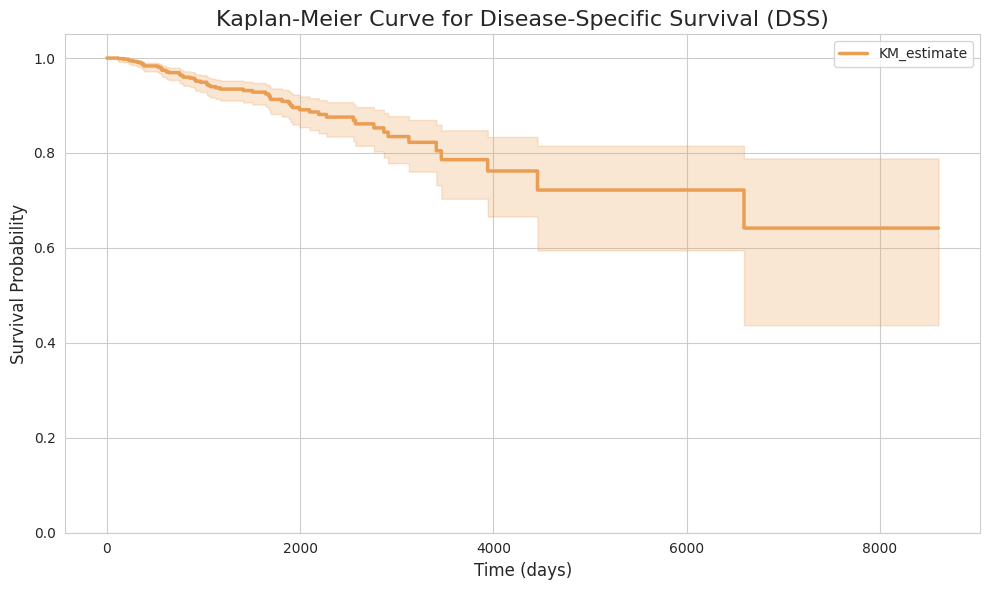

In [18]:
# Example for Disease-Specific Survival (DSS)
print("\n--- Preparing DSS Analysis ---")
print("Number of NaNs in 'DSS.time':", df['DSS.time'].isnull().sum())
print("Number of NaNs in 'DSS':", df['DSS'].isnull().sum())

df_dss_clean = df.dropna(subset=['DSS.time', 'DSS']).copy()

print(f"Dropped {len(df) - len(df_dss_clean)} rows with missing DSS data.")
print(f"New dataframe shape for DSS analysis: {df_dss_clean.shape}")

kmf_dss = KaplanMeierFitter()
kmf_dss.fit(durations=df_dss_clean['DSS.time'], event_observed=df_dss_clean['DSS'])

plt.figure(figsize=(10, 6))
kmf_dss.plot_survival_function(color=cmap_haline(0.7), linewidth=2.5)
plt.title('Kaplan-Meier Curve for Disease-Specific Survival (DSS)', fontsize=16)
plt.xlabel('Time (days)', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

Plotting KM curves for subtypes with > 30 patients: ['LumA', 'LumB', 'Basal', 'Her2', 'Normal']


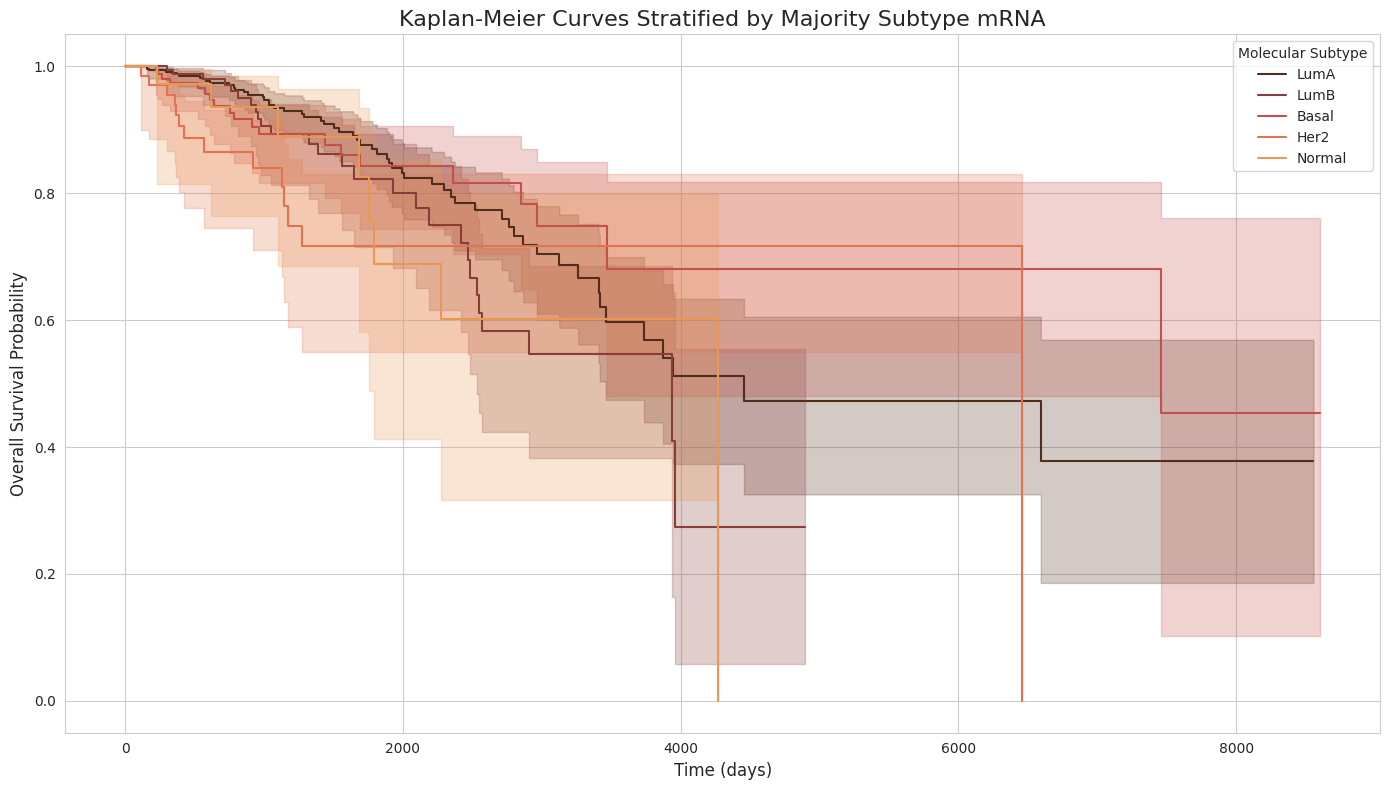

In [19]:
# --- Setup (assuming you have already loaded your df) ---
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Define colormaps
cmap_ice = cmc.batlow
cmap_haline = cmc.lajolla
cmap_turbid = cmc.vik
cmap_matter = cmc.imola

# Helper function for palettes
def generate_palette_from_cmap(cmap, n_colors):
    return [cmap(i) for i in np.linspace(0, 1, n_colors)]

# --- Data Preparation for Survival Analysis ---
# It's critical to drop rows with missing survival data
df_os_clean = df.dropna(subset=['OS.time', 'OS']).copy()

# --- Stratified Survival Analysis by Majority_Subtype_mRNA ---

# Get the count of patients per molecular subtype
subtype_counts = df_os_clean['Majority_Subtype_mRNA'].value_counts()

# Filter out subtypes with very few patients (e.g., less than 30)
# This ensures the curves are stable and meaningful
subtypes_to_plot = subtype_counts[subtype_counts > 30].index

print(f"Plotting KM curves for subtypes with > 30 patients: {list(subtypes_to_plot)}")

plt.figure(figsize=(14, 8))

# Loop through each subtype and plot its KM curve
for subtype in subtypes_to_plot:
    mask = df_os_clean['Majority_Subtype_mRNA'] == subtype
    kmf.fit(durations=df_os_clean.loc[mask, 'OS.time'], 
            event_observed=df_os_clean.loc[mask, 'OS'], 
            label=subtype)
    
    # Generate a distinct color for each subtype
    color_val = 0.2 + (list(subtypes_to_plot).index(subtype) * 0.6 / len(subtypes_to_plot))
    kmf.plot_survival_function(color=cmap_haline(color_val))

plt.title('Kaplan-Meier Curves Stratified by Majority Subtype mRNA', fontsize=16)
plt.xlabel('Time (days)', fontsize=12)
plt.ylabel('Overall Survival Probability', fontsize=12)
plt.legend(title='Molecular Subtype', loc='best', frameon=True)
plt.tight_layout()
plt.show()

In [20]:
# Example: Compare Luminal A vs. Basal-like subtypes
subtype_A = 'Luminal A'
subtype_B = 'Basal-like'

mask_A = (df_os_clean['Majority_Subtype_mRNA'] == subtype_A)
mask_B = (df_os_clean['Majority_Subtype_mRNA'] == subtype_B)

results = logrank_test(df_os_clean.loc[mask_A, 'OS.time'], 
                      df_os_clean.loc[mask_B, 'OS.time'],
                      event_observed_A=df_os_clean.loc[mask_A, 'OS'],
                      event_observed_B=df_os_clean.loc[mask_B, 'OS'])

print(f"Log-Rank Test between {subtype_A} and {subtype_B}:")
print(results)

NameError: name 'logrank_test' is not defined

/tmp/ipykernel_1299882/221003986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ajcc_pathologic_tumor_stage', y='age_at_initial_pathologic_diagnosis',
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found bec

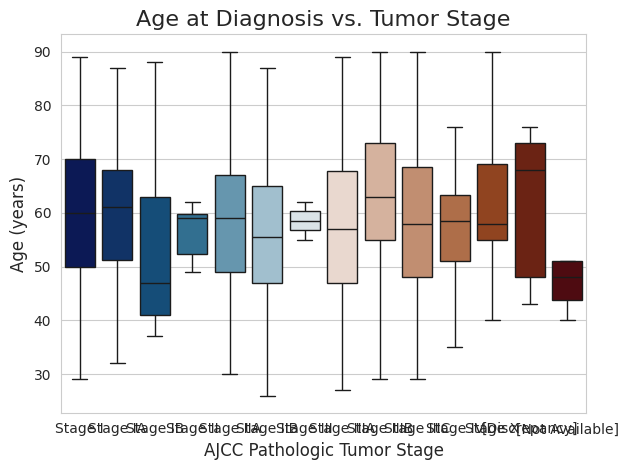

In [14]:
# Idea 5: Stratified Survival Curve (e.g., by Subtype)
stage_palette = generate_palette_from_cmap(cmap_turbid, n_stages)
sns.boxplot(data=df, x='ajcc_pathologic_tumor_stage', y='age_at_initial_pathologic_diagnosis', 
           order=sorted(df['ajcc_pathologic_tumor_stage'].dropna().unique()),
           palette=stage_palette)
plt.title('Age at Diagnosis vs. Tumor Stage', fontsize=16)
plt.xlabel('AJCC Pathologic Tumor Stage', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

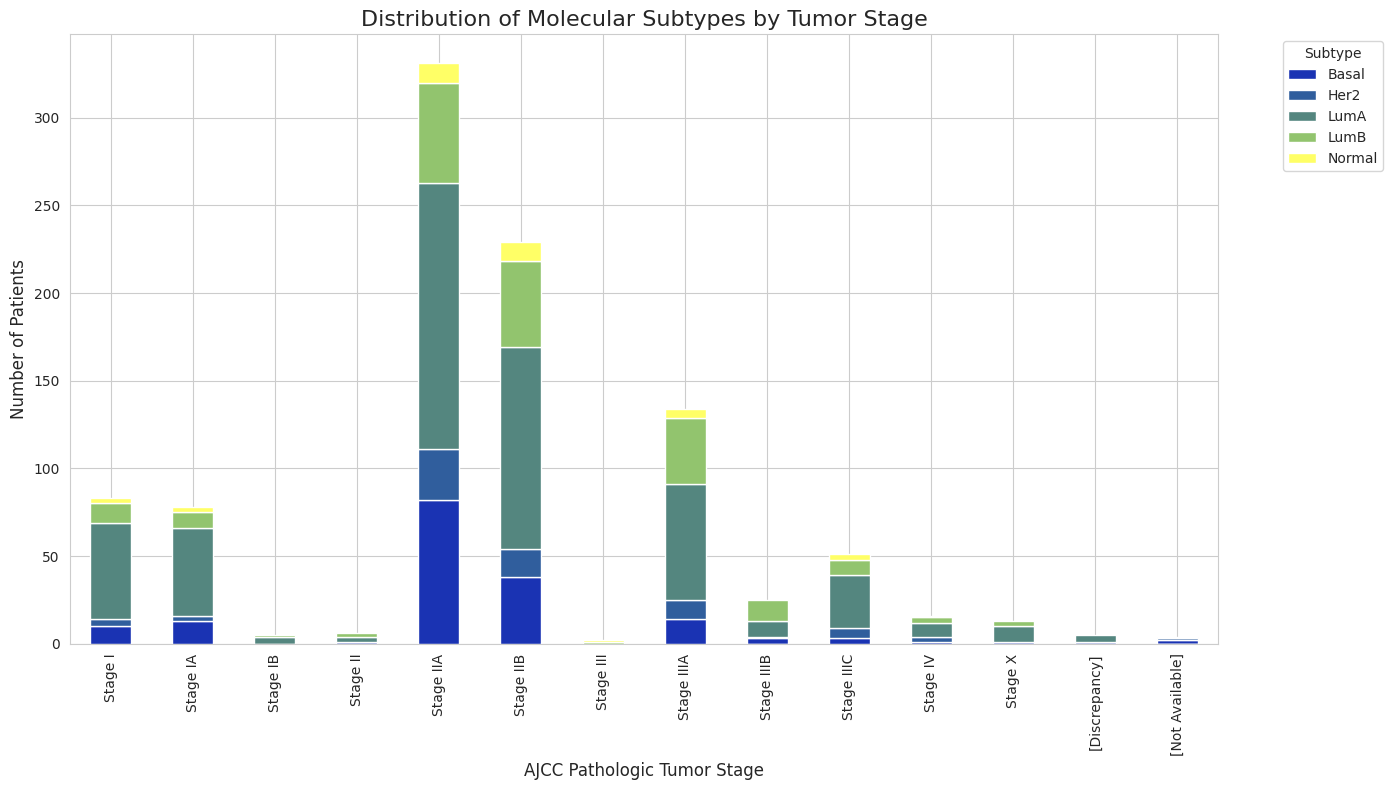

In [15]:
# Idea 7: Subtype Distribution by Tumor Stage
stage_subtype = pd.crosstab(df['ajcc_pathologic_tumor_stage'], df['Majority_Subtype_mRNA'])
stage_subtype.plot(kind='bar', stacked=True, figsize=(14, 8), colormap=cmap_matter)
plt.title('Distribution of Molecular Subtypes by Tumor Stage', fontsize=16)
plt.xlabel('AJCC Pathologic Tumor Stage', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1299882/1665251465.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ajcc_pathologic_tumor_stage', ax=axes[1],
/tmp/ipykernel_1299882/1665251465.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='menopause_status', ax=axes[2], palette=menopause_palette)
/tmp/ipykernel_1299882/1665251465.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Majority_Subtype_mRNA', ax=axes[3],
/tmp/ipykernel_1299882/1665251465.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is depre

TypeError: NaNs were detected in the dataset. Try using pd.isnull to find the problematic values.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

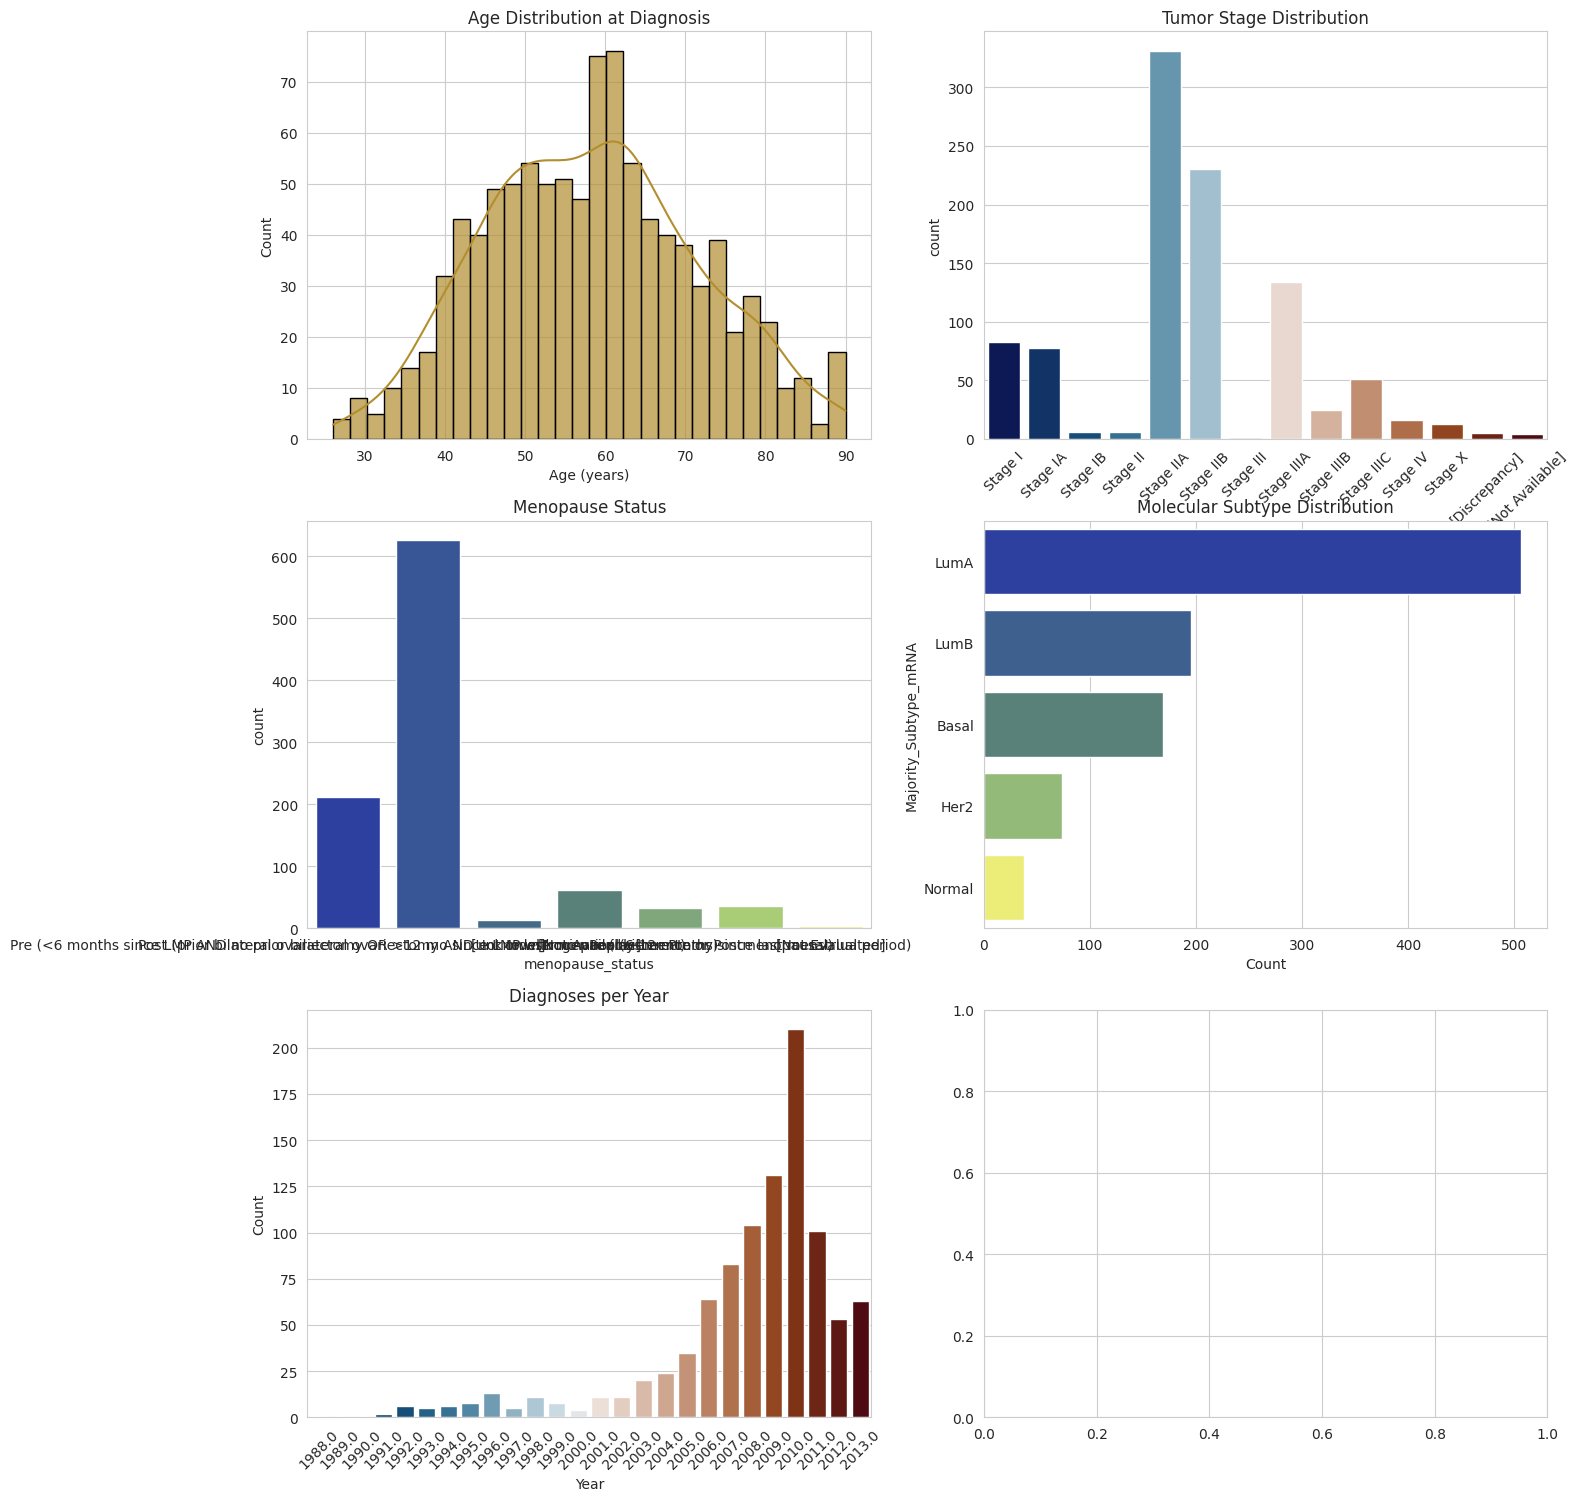

In [16]:
# --- Creating a Dashboard ---

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# 1. Age Distribution
sns.histplot(data=df, x='age_at_initial_pathologic_diagnosis', bins=30, 
            color=cmap_ice(0.6), kde=True, edgecolor='black', alpha=0.7, ax=axes[0])
axes[0].set_title('Age Distribution at Diagnosis')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

# 2. Tumor Stage Distribution
n_stages = len(df['ajcc_pathologic_tumor_stage'].dropna().unique())
stage_palette = generate_palette_from_cmap(cmap_turbid, n_stages)
sns.countplot(data=df, x='ajcc_pathologic_tumor_stage', ax=axes[1], 
             order=sorted(df['ajcc_pathologic_tumor_stage'].dropna().unique()),
             palette=stage_palette)
axes[1].set_title('Tumor Stage Distribution')
axes[1].tick_params(axis='x', rotation=45)

# 3. Menopause Status
n_menopause = len(df['menopause_status'].dropna().unique())
menopause_palette = generate_palette_from_cmap(cmap_matter, n_menopause)
sns.countplot(data=df, x='menopause_status', ax=axes[2], palette=menopause_palette)
axes[2].set_title('Menopause Status')

# 4. Subtype Distribution
n_subtypes = len(df['Majority_Subtype_mRNA'].dropna().unique())
subtype_palette = generate_palette_from_cmap(cmap_matter, n_subtypes)
sns.countplot(data=df, y='Majority_Subtype_mRNA', ax=axes[3], 
             order=df['Majority_Subtype_mRNA'].value_counts().index,
             palette=subtype_palette)
axes[3].set_title('Molecular Subtype Distribution')
axes[3].set_xlabel('Count')

# 5. Diagnosis Year Trend
sns.countplot(data=df, x='initial_pathologic_dx_year', ax=axes[4], 
             order=sorted(df['initial_pathologic_dx_year'].dropna().unique()),
             palette=generate_palette_from_cmap(cmap_turbid, len(df['initial_pathologic_dx_year'].dropna().unique())))
axes[4].set_title('Diagnoses per Year')
axes[4].set_xlabel('Year')
axes[4].set_ylabel('Count')
axes[4].tick_params(axis='x', rotation=45)

# 6. Kaplan-Meier Curve
kmf.fit(durations=df['OS.time'], event_observed=df['OS'])
kmf.plot_survival_function(color=cmap_matter(0.7), linewidth=2.5, ax=axes[5])
axes[5].set_title('Overall Survival (OS)')
axes[5].set_xlabel('Time (days)')
axes[5].set_ylabel('Survival Probability')
axes[5].set_ylim(0, 1.05)

plt.suptitle('Breast Cancer Dataset Statistics Dashboard', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()